In [8]:
import glob
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visual formatting defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["legend.frameon"] = True

print("✓ Environment configured successfully.")

✓ Environment configured successfully.


In [9]:
workspace = Path.home() / "bicycle-architecture-compiler" / "saved_metrics"

# 1. Discover and load Dutta metrics CSV files
target_file = workspace / "dutta_metrics.csv"
if target_file.exists():
  csv_files = [str(target_file)]
else:
  csv_files = sorted(glob.glob(str(workspace / "*dutta*.csv")))
  if not csv_files:
    # Fallback to general workspace
    csv_files = sorted(
        glob.glob(
            str(
                Path.home()
                / "bicycle-architecture-compiler"
                / "*dutta*.csv"
            )
        )
    )

if not csv_files:
  raise FileNotFoundError(f"No Dutta metrics CSV files found in {workspace}")

df_list = [pd.read_csv(f) for f in csv_files]
master_df = pd.concat(df_list, ignore_index=True)

# 2. Support both 'circuit' and 'adder' column naming
circuit_col = "circuit" if "circuit" in master_df.columns else "adder"
master_df = master_df.drop_duplicates(subset=[circuit_col, "partition"])


# 3. Extract Circuit Family Name and Control Count (n)
def parse_circuit(name):
  m = re.match(r"([a-z_]+)_n(\d+)", str(name))
  if m:
    return m.group(1), int(m.group(2))
  return str(name), 0


master_df[["family", "n_controls"]] = master_df[circuit_col].apply(
    lambda x: pd.Series(parse_circuit(x))
)

# 4. Standardize numeric types and column aliases
numeric_targets = [
    "measurement_depth",
    "end_time",
    "total_error",
    "failure_prob",
    "automorphisms",
    "measurements",
    "allocated_qubits",
    "pbc_steps",
    "im_gates",
    "im_hops",
    "factory_im_hops",
    "factory_delivery_hops",
    "total_im_hops",
]
for col in numeric_targets:
  if col in master_df.columns:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce")

if (
    "factory_delivery_hops" in master_df.columns
    and "factory_im_hops" not in master_df.columns
):
  master_df["factory_im_hops"] = master_df["factory_delivery_hops"]

# 5. Metrics to compute deltas for relative to unpartitioned 'original' baseline
delta_metric_targets = [
    ("measurement_depth", "depth_diff", "depth_pct"),
    ("end_time", "time_diff", "time_pct"),
    ("im_gates", "im_gates_diff", "im_gates_pct"),
    ("im_hops", "im_hops_diff", "im_hops_pct"),
    ("factory_im_hops", "factory_hops_diff", "factory_hops_pct"),
    ("total_im_hops", "total_im_hops_diff", "total_im_hops_pct"),
    ("measurements", "measurements_diff", "measurements_pct"),
    ("automorphisms", "automorphisms_diff", "automorphisms_pct"),
    ("total_error", "total_error_diff", "total_error_pct"),
]

rows = []
for (fam, n), group in master_df.groupby(["family", "n_controls"]):
  orig_rows = group[group["partition"] == "original"]
  if orig_rows.empty:
    continue
  orig = orig_rows.iloc[0]

  for _, row in group.iterrows():
    d = row.to_dict()

    # Dynamic module allocation count
    cap = (
        11
        if (
            "allocated_qubits" in row
            and row["allocated_qubits"] % 11 == 0
        )
        else 12
    )
    d["modules"] = (
        row["allocated_qubits"] // cap
        if "allocated_qubits" in row
        else np.nan
    )

    for col, diff_col, pct_col in delta_metric_targets:
      if col in row and col in orig and pd.notna(row[col]) and pd.notna(orig[col]):
        val = row[col]
        orig_val = orig[col]
        d[diff_col] = val - orig_val
        d[pct_col] = (
            ((val - orig_val) / orig_val) * 100.0 if orig_val != 0 else 0.0
        )

    rows.append(d)

df_all = pd.DataFrame(rows).sort_values(by=["n_controls", "partition"])

# Partition ordering, line styling, and color mapping
preferred_order = [
    "original",
    "weighted_degree",
    "metis",
    "kahypar",
    #"clustering",
]
partition_order = [p for p in preferred_order if p in df_all["partition"].unique()]
# for p in df_all["partition"].unique():
#   if p not in partition_order:
#     partition_order.append(p)

part_palette = {
    "original": "#333333",
    "weighted_degree": "#4C72B0",
    "metis": "#55A868",
    "kahypar": "#C44E52",
    #"clustering": "#E4A10F",
}
part_markers = {
    "original": "o",
    "weighted_degree": "s",
    "metis": "^",
    "kahypar": "D",
    #"clustering": "v",
}
part_linestyles = {
    "original": "--",
    "weighted_degree": "-",
    "metis": "-",
    "kahypar": "-",
    #"clustering": "-",
}

n_range = sorted(df_all["n_controls"].unique())
print(f"✓ Successfully processed {len(df_all)} configurations.")
print(f"  • Controls sweep range: n = {min(n_range)} to {max(n_range)} ({len(n_range)} points)")
print(f"  • Partitions detected: {partition_order}")

✓ Successfully processed 235 configurations.
  • Controls sweep range: n = 4 to 50 (47 points)
  • Partitions detected: ['original', 'weighted_degree', 'metis', 'kahypar']


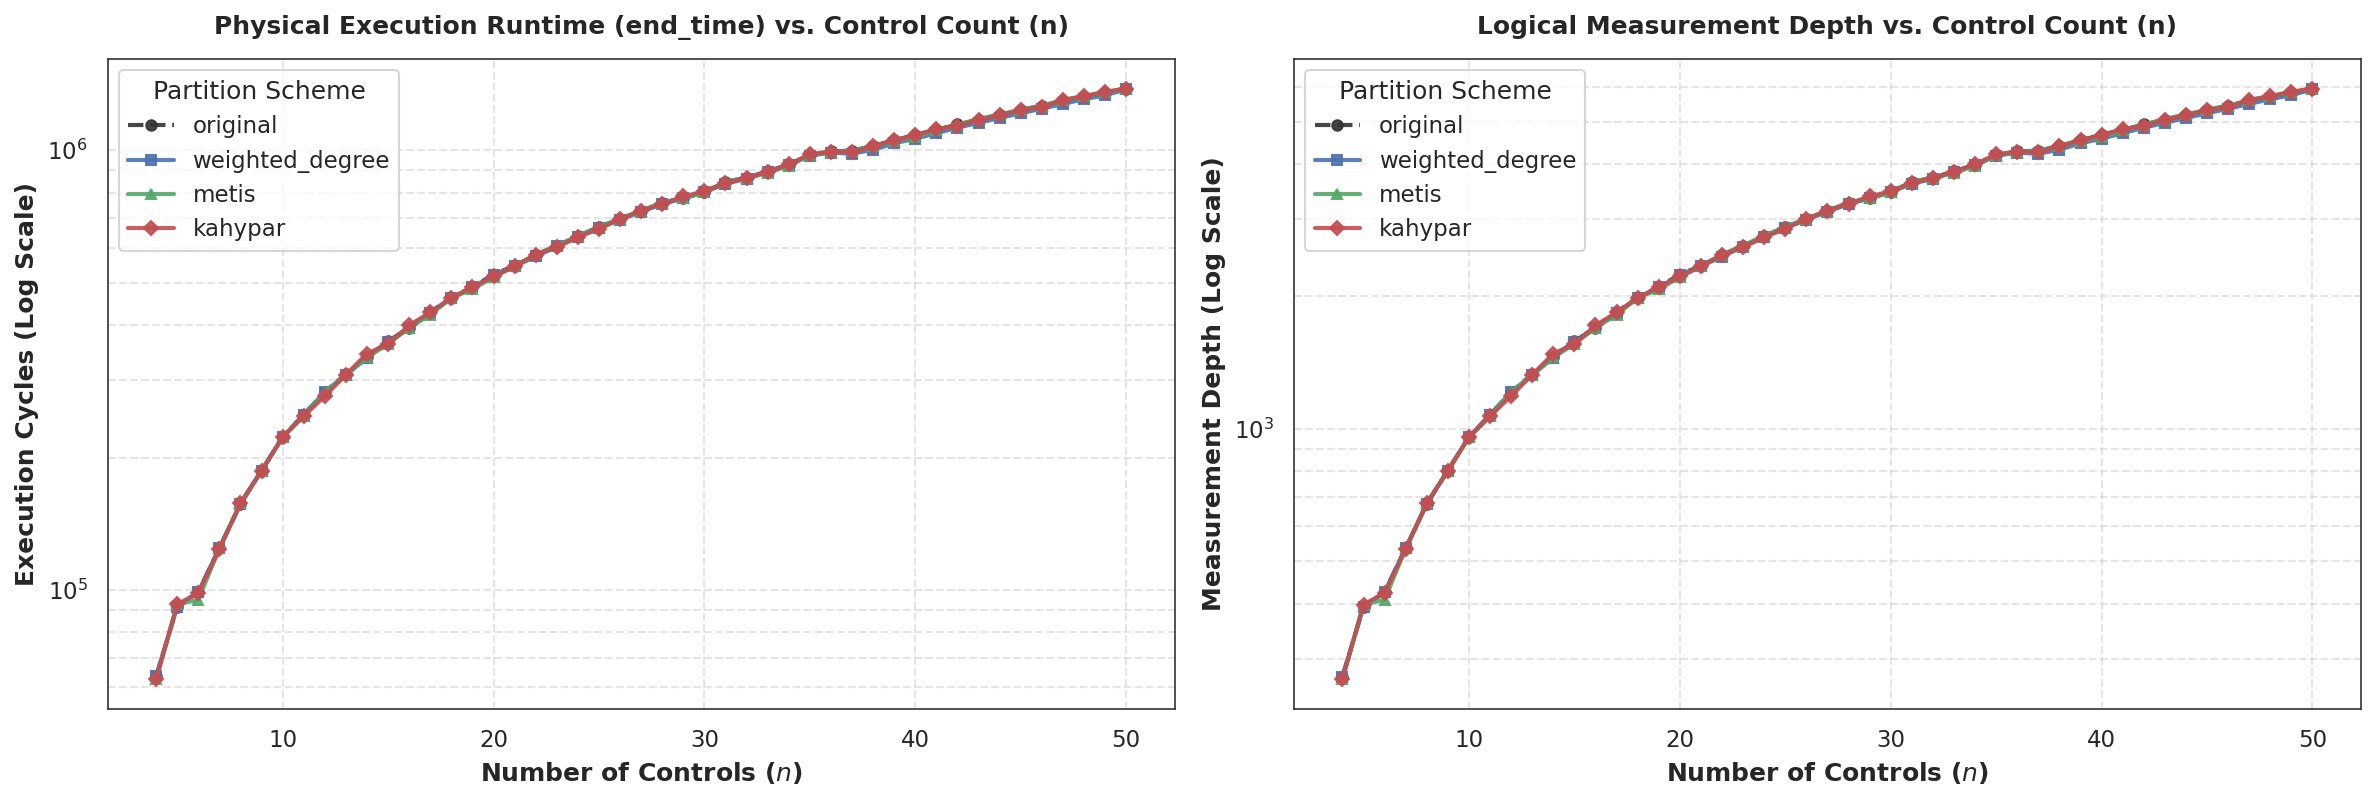

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel A: Physical Execution Cycles (end_time)
for part in partition_order:
  sub = df_all[df_all["partition"] == part].sort_values("n_controls")
  axes[0].plot(
      sub["n_controls"],
      sub["end_time"],
      label=part,
      color=part_palette.get(part, "#777777"),
      marker=part_markers.get(part, "o"),
      linestyle=part_linestyles.get(part, "-"),
      linewidth=2.0,
      markersize=5,
      alpha=0.9,
  )

axes[0].set_title(
    "Physical Execution Runtime (end_time) vs. Control Count (n)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[0].set_xlabel("Number of Controls ($n$)", fontweight="bold")
axes[0].set_ylabel("Execution Cycles (Log Scale)", fontweight="bold")
axes[0].set_yscale("log")
axes[0].grid(True, which="both", linestyle="--", alpha=0.5)
axes[0].legend(title="Partition Scheme", loc="upper left")

# Panel B: Logical Measurement Layer Depth
for part in partition_order:
  sub = df_all[df_all["partition"] == part].sort_values("n_controls")
  axes[1].plot(
      sub["n_controls"],
      sub["measurement_depth"],
      label=part,
      color=part_palette.get(part, "#777777"),
      marker=part_markers.get(part, "o"),
      linestyle=part_linestyles.get(part, "-"),
      linewidth=2.0,
      markersize=5,
      alpha=0.9,
  )

axes[1].set_title(
    "Logical Measurement Depth vs. Control Count (n)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[1].set_xlabel("Number of Controls ($n$)", fontweight="bold")
axes[1].set_ylabel("Measurement Depth (Log Scale)", fontweight="bold")
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)
axes[1].legend(title="Partition Scheme", loc="upper left")

plt.tight_layout()
plt.show()

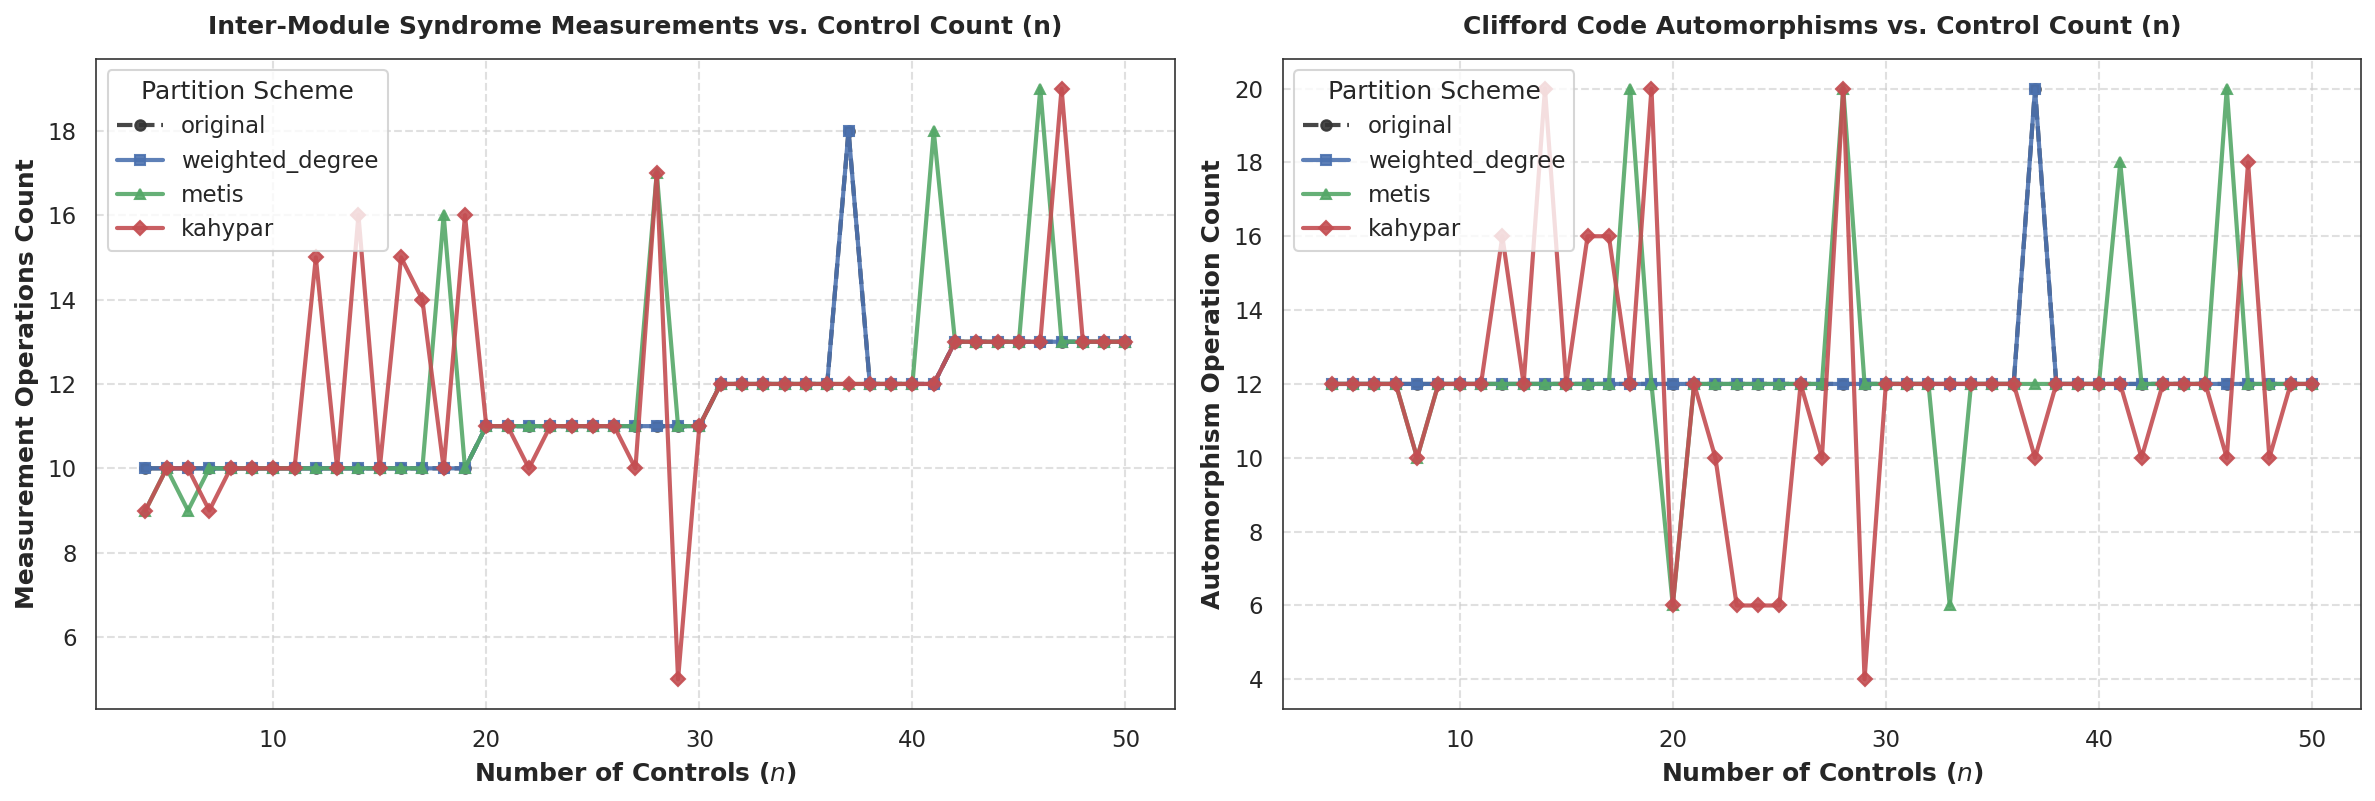

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel A: Physical Multi-Qubit Syndrome Measurements (Cuts)
for part in partition_order:
  sub = df_all[df_all["partition"] == part].sort_values("n_controls")
  axes[0].plot(
      sub["n_controls"],
      sub["measurements"],
      label=part,
      color=part_palette.get(part, "#777777"),
      marker=part_markers.get(part, "o"),
      linestyle=part_linestyles.get(part, "-"),
      linewidth=2.0,
      markersize=5,
      alpha=0.9,
  )

axes[0].set_title(
    "Inter-Module Syndrome Measurements vs. Control Count (n)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[0].set_xlabel("Number of Controls ($n$)", fontweight="bold")
axes[0].set_ylabel("Measurement Operations Count", fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(title="Partition Scheme", loc="upper left")

# Panel B: Clifford Code Automorphisms (Permutations)
for part in partition_order:
  sub = df_all[df_all["partition"] == part].sort_values("n_controls")
  axes[1].plot(
      sub["n_controls"],
      sub["automorphisms"],
      label=part,
      color=part_palette.get(part, "#777777"),
      marker=part_markers.get(part, "o"),
      linestyle=part_linestyles.get(part, "-"),
      linewidth=2.0,
      markersize=5,
      alpha=0.9,
  )

axes[1].set_title(
    "Clifford Code Automorphisms vs. Control Count (n)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[1].set_xlabel("Number of Controls ($n$)", fontweight="bold")
axes[1].set_ylabel("Automorphism Operation Count", fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(title="Partition Scheme", loc="upper left")

plt.tight_layout()
plt.show()

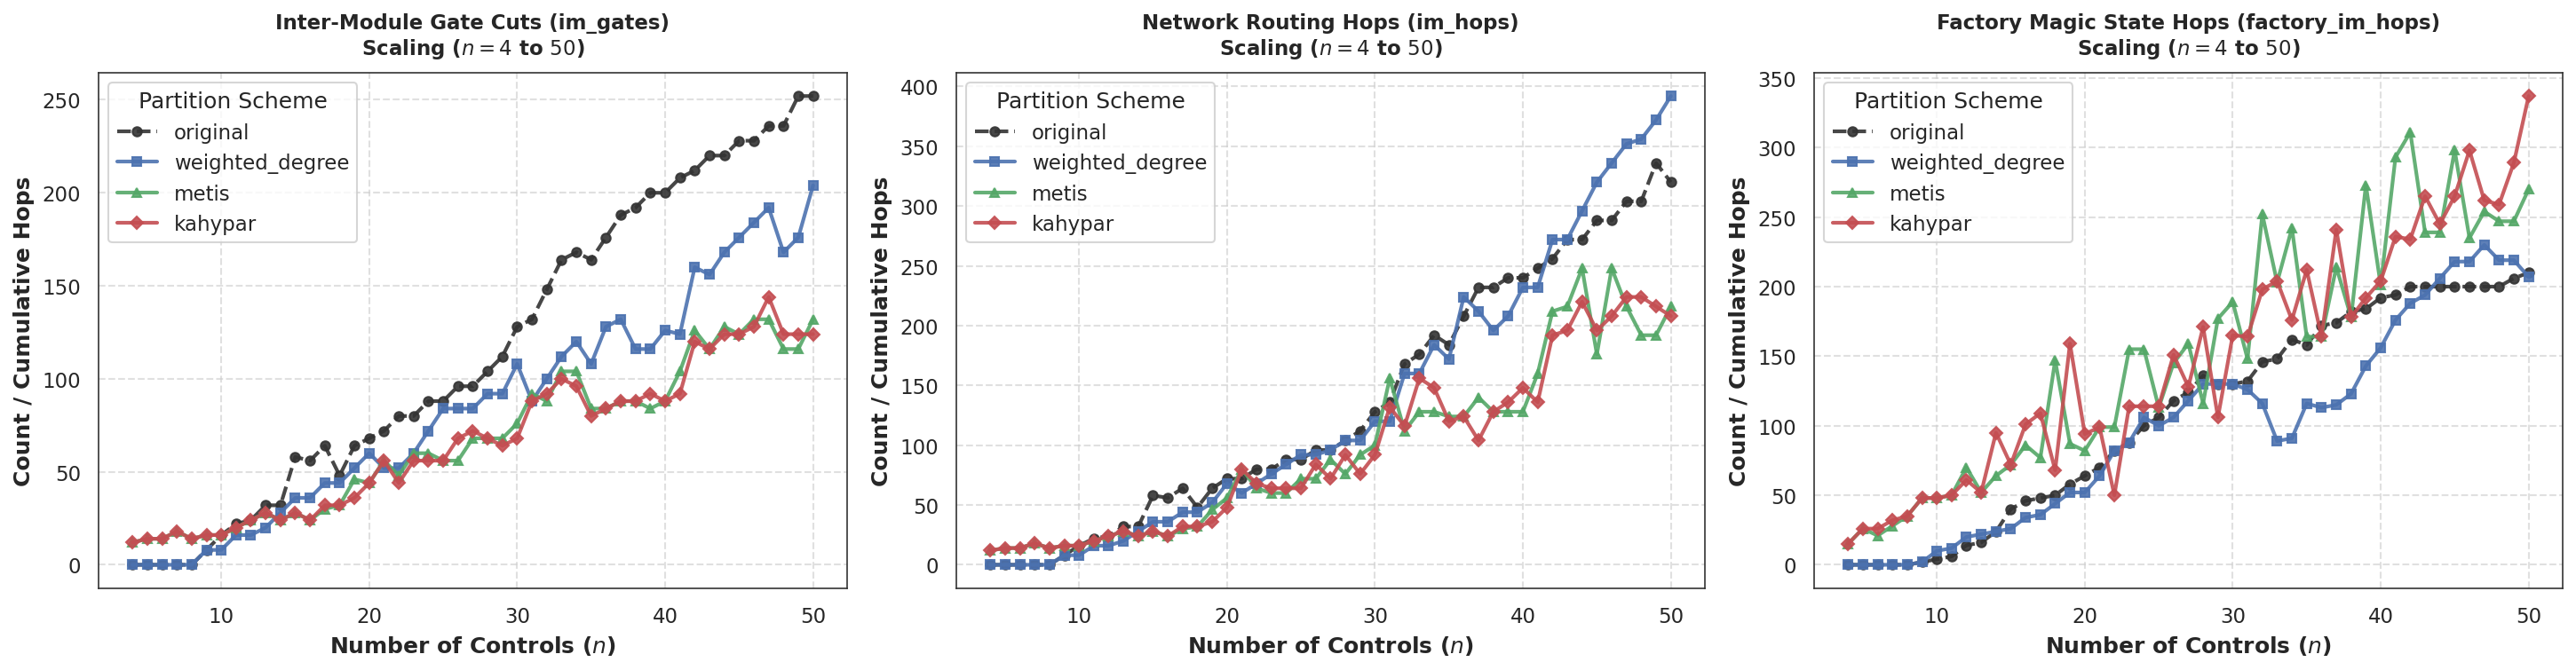

In [12]:
im_metrics_available = [
    m for m in ["im_gates", "im_hops", "factory_im_hops"] if m in df_all.columns
]

if not im_metrics_available:
  print(
      "Analytical IM metrics not found in dataset. Ensure"
      " run_dutta_benchmarks.py has logged them."
  )
else:
  n_plots = len(im_metrics_available)
  fig, axes = plt.subplots(1, n_plots, figsize=(6.5 * n_plots, 5.2))
  if n_plots == 1:
    axes = [axes]

  titles = {
      "im_gates": "Inter-Module Gate Cuts (im_gates)",
      "im_hops": "Network Routing Hops (im_hops)",
      "factory_im_hops": "Factory Magic State Hops (factory_im_hops)",
  }

  for idx, metric in enumerate(im_metrics_available):
    ax = axes[idx]
    for part in partition_order:
      sub = df_all[df_all["partition"] == part].sort_values("n_controls")
      ax.plot(
          sub["n_controls"],
          sub[metric],
          label=part,
          color=part_palette.get(part, "#777777"),
          marker=part_markers.get(part, "o"),
          linestyle=part_linestyles.get(part, "-"),
          linewidth=2.0,
          markersize=5,
          alpha=0.9,
      )

    ax.set_title(
        f"{titles.get(metric, metric)}\nScaling ($n=4$ to $50$)",
        fontsize=11,
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("Number of Controls ($n$)", fontweight="bold")
    ax.set_ylabel("Count / Cumulative Hops", fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Partition Scheme", loc="upper left")

  plt.tight_layout()
  plt.show()

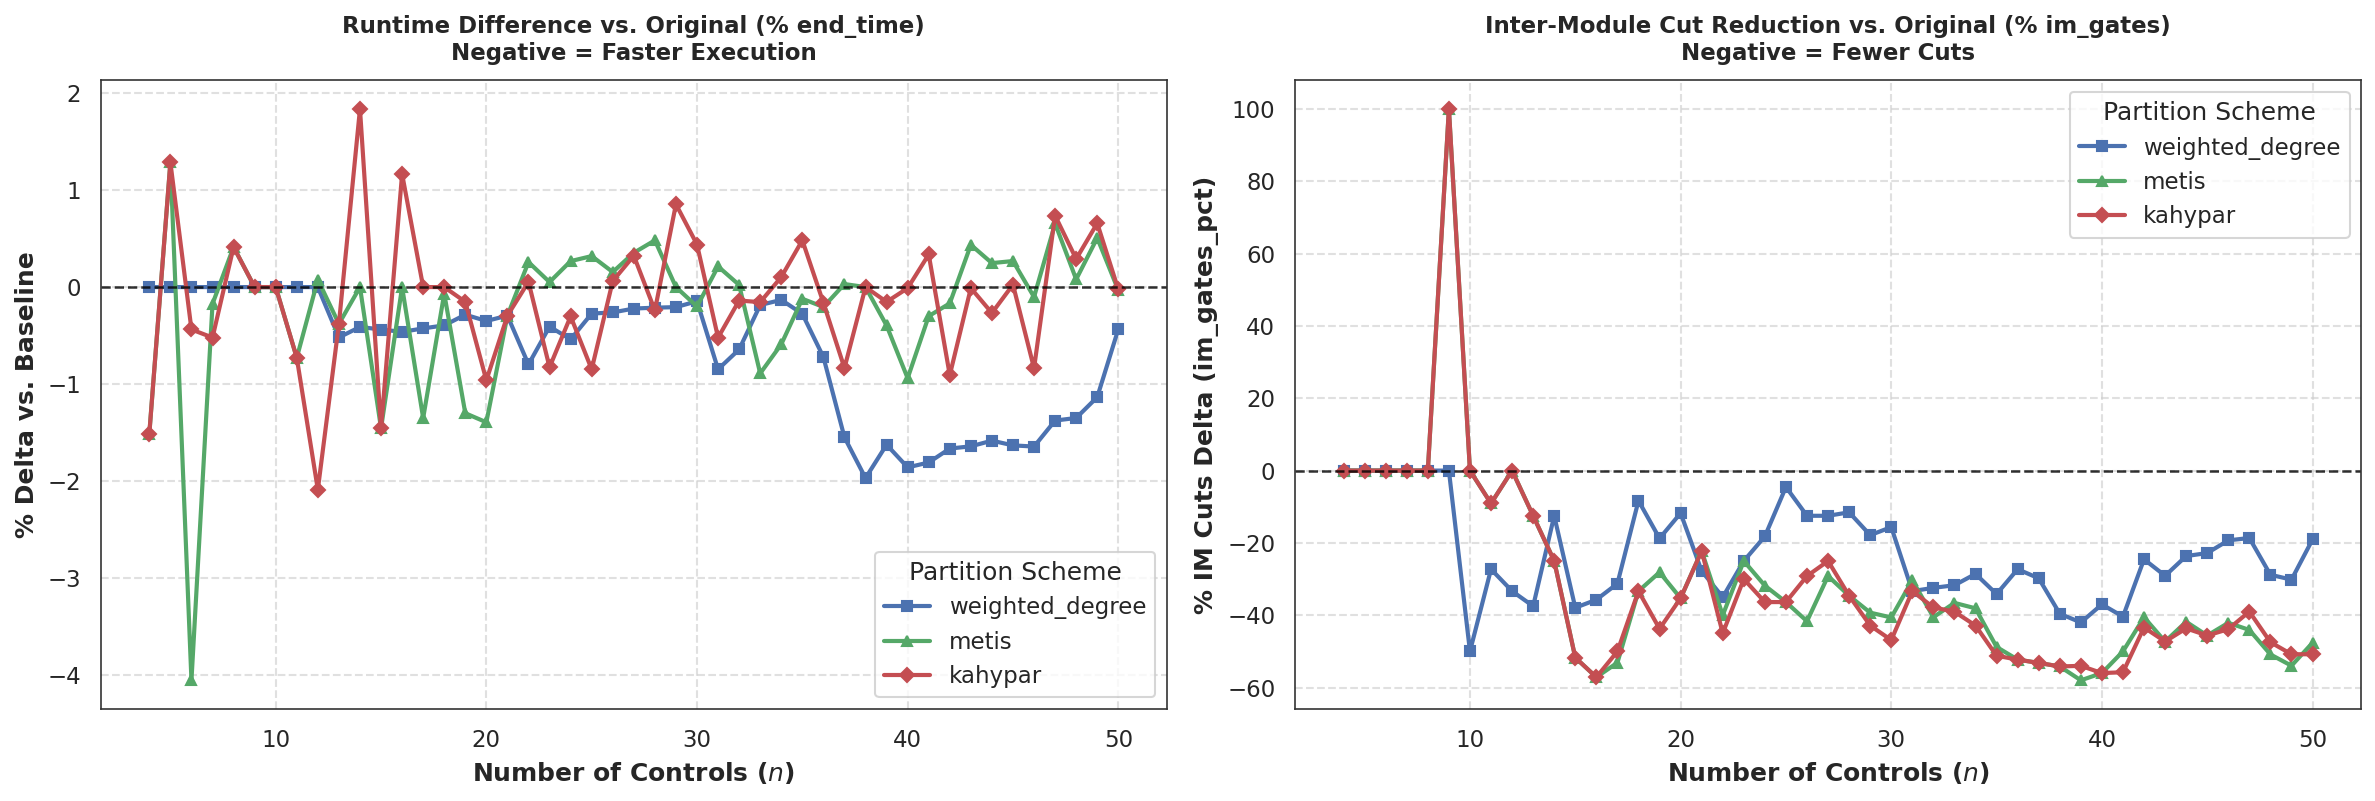

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
non_base_schemes = [p for p in partition_order if p != "original"]

# Panel A: Execution Cycles % Delta vs Original
for part in non_base_schemes:
  sub = df_all[df_all["partition"] == part].sort_values("n_controls")
  axes[0].plot(
      sub["n_controls"],
      sub["time_pct"],
      label=part,
      color=part_palette.get(part, "#777777"),
      marker=part_markers.get(part, "o"),
      linewidth=2.0,
      markersize=5,
  )

axes[0].axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
axes[0].set_title(
    "Runtime Difference vs. Original (% end_time)\nNegative = Faster Execution",
    fontsize=11,
    fontweight="bold",
    pad=10,
)
axes[0].set_xlabel("Number of Controls ($n$)", fontweight="bold")
axes[0].set_ylabel("% Delta vs. Baseline", fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(title="Partition Scheme", loc="best")

# Panel B: Inter-Module Gate Cuts % Delta vs Original
im_gate_col = "im_gates_pct" if "im_gates_pct" in df_all.columns else "depth_pct"
ylabel_text = (
    "% IM Cuts Delta (im_gates_pct)"
    if im_gate_col == "im_gates_pct"
    else "% Depth Delta (depth_pct)"
)
title_text = (
    "Inter-Module Cut Reduction vs. Original (% im_gates)\nNegative = Fewer"
    " Cuts"
    if im_gate_col == "im_gates_pct"
    else "Measurement Depth Delta vs. Original (%)"
)

for part in non_base_schemes:
  sub = df_all[df_all["partition"] == part].sort_values("n_controls")
  axes[1].plot(
      sub["n_controls"],
      sub[im_gate_col],
      label=part,
      color=part_palette.get(part, "#777777"),
      marker=part_markers.get(part, "o"),
      linewidth=2.0,
      markersize=5,
  )

axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
axes[1].set_title(title_text, fontsize=11, fontweight="bold", pad=10)
axes[1].set_xlabel("Number of Controls ($n$)", fontweight="bold")
axes[1].set_ylabel(ylabel_text, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(title="Partition Scheme", loc="best")

plt.tight_layout()
plt.show()

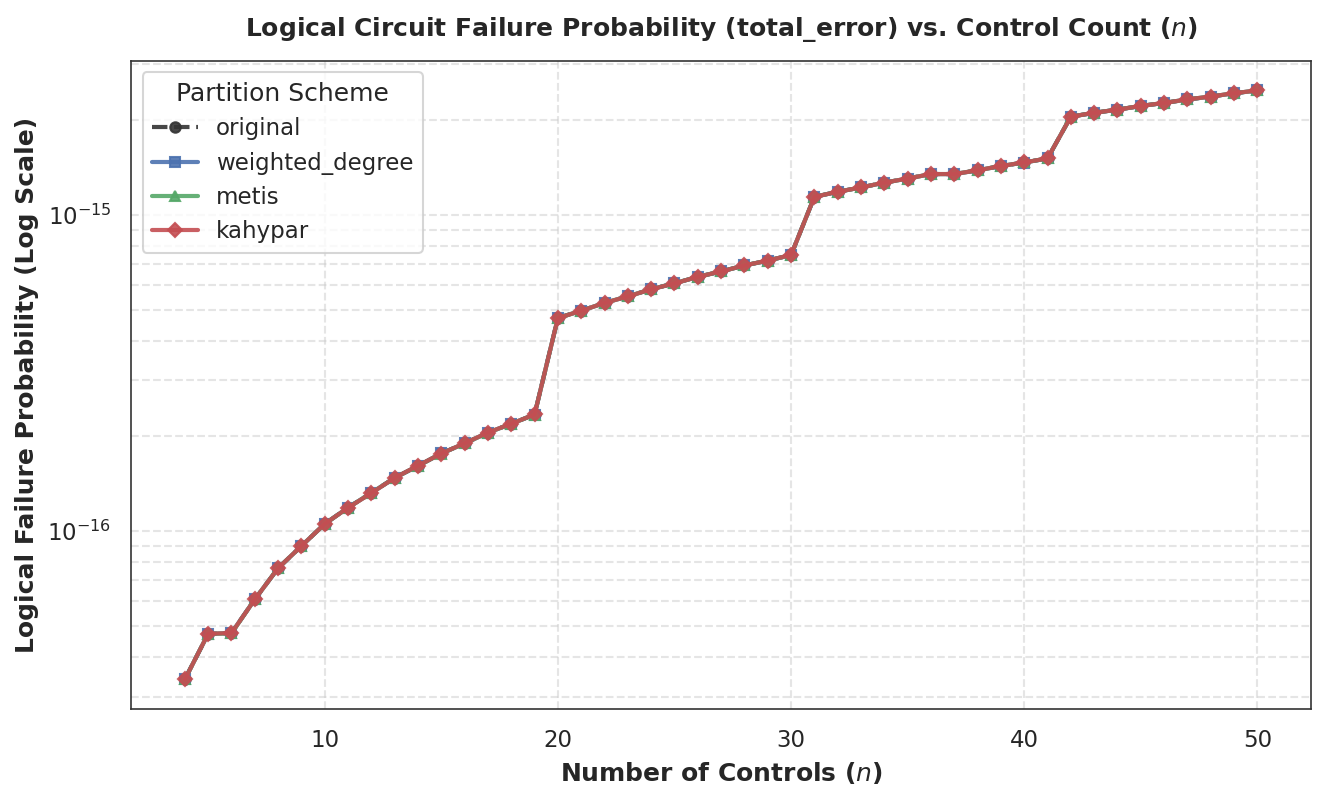

In [14]:
error_col = (
    "failure_prob"
    if "failure_prob" in df_all.columns
    else ("total_error" if "total_error" in df_all.columns else None)
)

if error_col is None:
  print("Skipping Error Rate Plot: error columns not found.")
else:
  fig, ax = plt.subplots(figsize=(9, 5.5))

  for part in partition_order:
    sub = df_all[df_all["partition"] == part].sort_values("n_controls")
    ax.plot(
        sub["n_controls"],
        sub[error_col],
        label=part,
        color=part_palette.get(part, "#777777"),
        marker=part_markers.get(part, "o"),
        linestyle=part_linestyles.get(part, "-"),
        linewidth=2.0,
        markersize=5,
        alpha=0.9,
    )

  ax.set_title(
      f"Logical Circuit Failure Probability ({error_col}) vs. Control Count"
      " ($n$)",
      fontsize=12,
      fontweight="bold",
      pad=12,
  )
  ax.set_xlabel("Number of Controls ($n$)", fontweight="bold")
  ax.set_ylabel("Logical Failure Probability (Log Scale)", fontweight="bold")
  ax.set_yscale("log")
  ax.grid(True, which="both", linestyle="--", alpha=0.5)
  ax.legend(title="Partition Scheme", loc="upper left")

  plt.tight_layout()
  plt.show()